Session 4 - RFM Segmentation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("../data/cleaned/online_retail_cleaned.csv")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df.shape)
df.head()

(397884, 13)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,InvoiceDay,InvoiceHour,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12-01,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12-01,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,8,Wednesday


Building the customer level RFM table

In [3]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [4]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate" : lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo" : "nunique",
    "Revenue" : "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]
print(rfm.head(20))

    CustomerID  Recency  Frequency  Monetary
0      12346.0      326          1  77183.60
1      12347.0        2          7   4310.00
2      12348.0       75          4   1797.24
3      12349.0       19          1   1757.55
4      12350.0      310          1    334.40
5      12352.0       36          8   2506.04
6      12353.0      204          1     89.00
7      12354.0      232          1   1079.40
8      12355.0      214          1    459.40
9      12356.0       23          3   2811.43
10     12357.0       33          1   6207.67
11     12358.0        2          2   1168.06
12     12359.0       58          4   6372.58
13     12360.0       52          3   2662.06
14     12361.0      287          1    189.90
15     12362.0        3         10   5226.23
16     12363.0      110          2    552.00
17     12364.0        8          4   1313.10
18     12365.0      291          2    641.38
19     12367.0        4          1    168.90


In [5]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


------------------------------------------------------------------------------------------------------

RFM Histogram

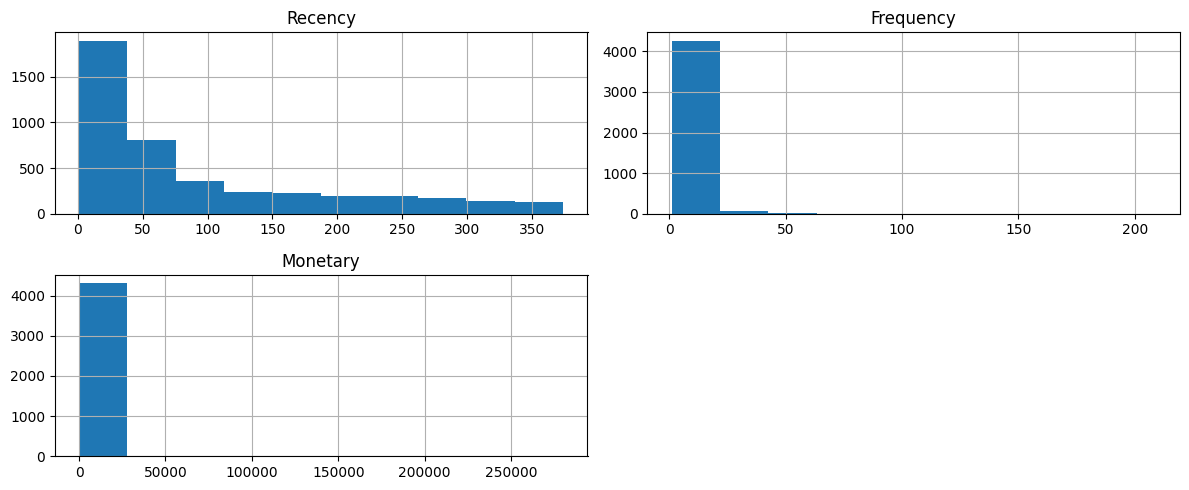

In [6]:
rfm[["Recency", "Frequency", "Monetary"]].hist(figsize=(12,5))
plt.tight_layout()
plt.show()

RFM Boxplots

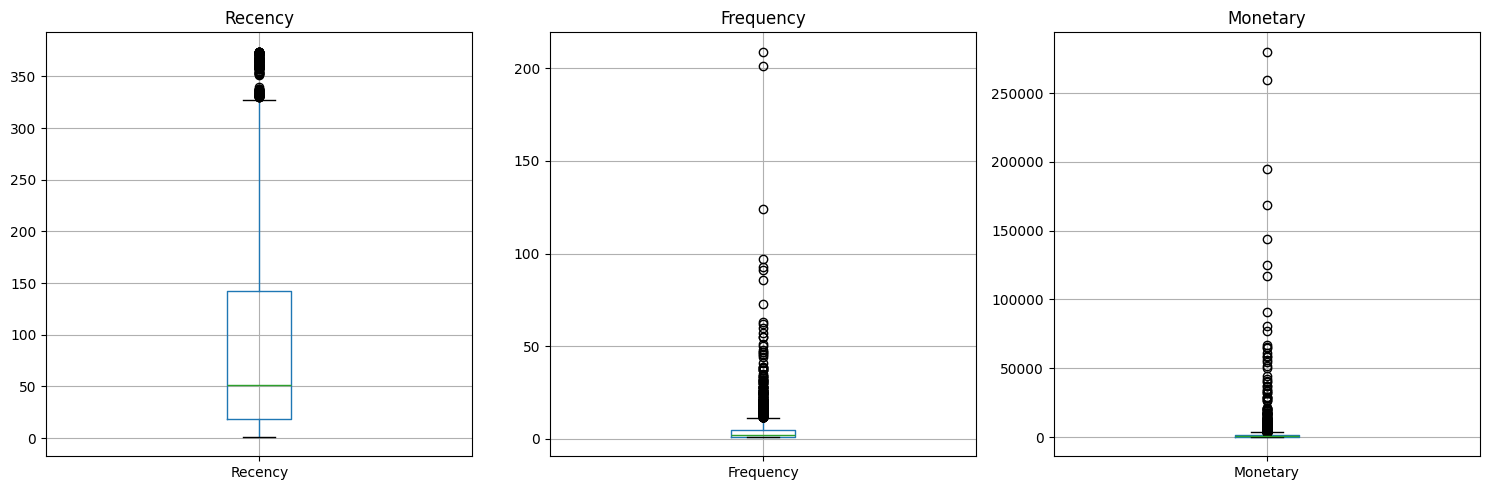

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

rfm.boxplot(column="Recency", ax=axes[0])
axes[0].set_title("Recency")

rfm.boxplot(column="Frequency", ax=axes[1])
axes[1].set_title("Frequency")

rfm.boxplot(column="Monetary", ax=axes[2])
axes[2].set_title("Monetary")

plt.tight_layout()
plt.show()

------------------------------------------------------------------------------------------------------

Segmenting the RFM data

1. RFM scoring - This means turning each Recency, Frequency, and Monetary into a score from 1-4

In [8]:
RScore = rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
FScore = rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
MScore = rfm["M_Score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])
print(RScore, FScore, MScore)


0       1
1       4
2       2
3       3
4       1
       ..
4333    1
4334    1
4335    4
4336    4
4337    3
Name: Recency, Length: 4338, dtype: category
Categories (4, int64): [4 < 3 < 2 < 1] 0       1
1       4
2       3
3       1
4       1
       ..
4333    2
4334    2
4335    3
4336    4
4337    3
Name: Frequency, Length: 4338, dtype: category
Categories (4, int64): [1 < 2 < 3 < 4] 0       4
1       4
2       4
3       4
4       2
       ..
4333    1
4334    1
4335    1
4336    4
4337    4
Name: Monetary, Length: 4338, dtype: category
Categories (4, int64): [1 < 2 < 3 < 4]


In [9]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [10]:
rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,1,77183.60,1,1,4,6
1,12347.0,2,7,4310.00,4,4,4,12
2,12348.0,75,4,1797.24,2,3,4,9
3,12349.0,19,1,1757.55,3,1,4,8
4,12350.0,310,1,334.40,1,1,2,4


Creating simple score based segments based off the RFM score

In [11]:
def segment_customer(score):
    if score >= 10:
        return "High Value"
    elif score >= 7:
        return "Mid Value"
    elif score >= 5:
        return "Low Value"
    else:
        return "At Risk"

rfm["Segment"] = rfm["RFM_Score"].apply(segment_customer)
rfm.head(20)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,1,77183.60,1,1,4,6,Low Value
1,12347.0,2,7,4310.00,4,4,4,12,High Value
2,12348.0,75,4,1797.24,2,3,4,9,Mid Value
3,12349.0,19,1,1757.55,3,1,4,8,Mid Value
4,12350.0,310,1,334.40,1,1,2,4,At Risk
5,12352.0,36,8,2506.04,3,4,4,11,High Value
6,12353.0,204,1,89.00,1,1,1,3,At Risk
7,12354.0,232,1,1079.40,1,1,3,5,Low Value
8,12355.0,214,1,459.40,1,1,2,4,At Risk
9,12356.0,23,3,2811.43,3,3,4,10,High Value


In [12]:
rfm["Segment"].value_counts()

Segment
Mid Value     1275
High Value    1268
Low Value      988
At Risk        807
Name: count, dtype: int64

In [13]:
rfm.groupby("Segment")[["Recency", "Frequency", "Monetary", "RFM_Score"]].mean()

,Recency,Frequency,Monetary,RFM_Score
Segment,,,,
At Risk,229.620818,1.058240,222.570706,3.624535
High Value,19.896688,9.913249,5397.511680,11.078076
Low Value,114.564777,1.471660,521.962541,5.510121
Mid Value,60.941176,2.865882,1076.117289,7.983529


The RFM segmentation helps recognizing the different type of customers and will help the retailer retain the most amount of customers along with providing better deals to the loyal customers.

------------------------------------------------------------------------------------------------------

2. K-means clustering - used to group customers with similar purchasing behavior based on recency, frequency, and monetary value.

In [14]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

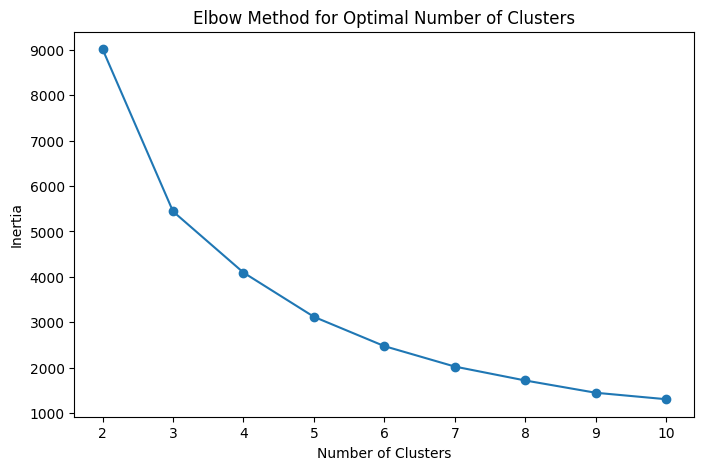

In [15]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

Based on the graph above, 4 clusters seems like the perfect option based on the inertia change.

In [16]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster = rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)
print(cluster)

[3 0 0 ... 0 3 0]


In [17]:
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


In [18]:
cluster_labels = {
    0: "Low value customers",
    1: "At risk or inactive customers",
    2: "Loyal High-Value customers",
    3: "Occasional Customers"
}

rfm["Cluster_Label"] = rfm["Cluster"].map(cluster_labels)


------------------------------------------------------------------------------------------------------

Visualizing the segment counts to create business recommendation

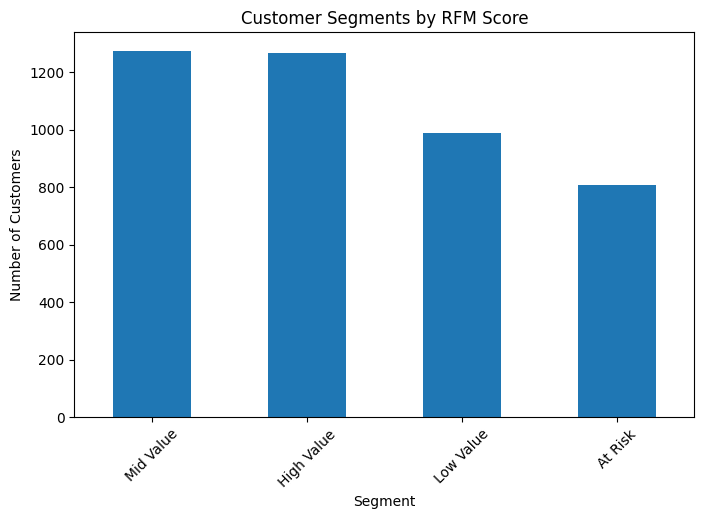

Segment
Mid Value     1275
High Value    1268
Low Value      988
At Risk        807
Name: count, dtype: int64


In [19]:
rfm["Segment"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Customer Segments by RFM Score")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()
print(rfm["Segment"].value_counts())

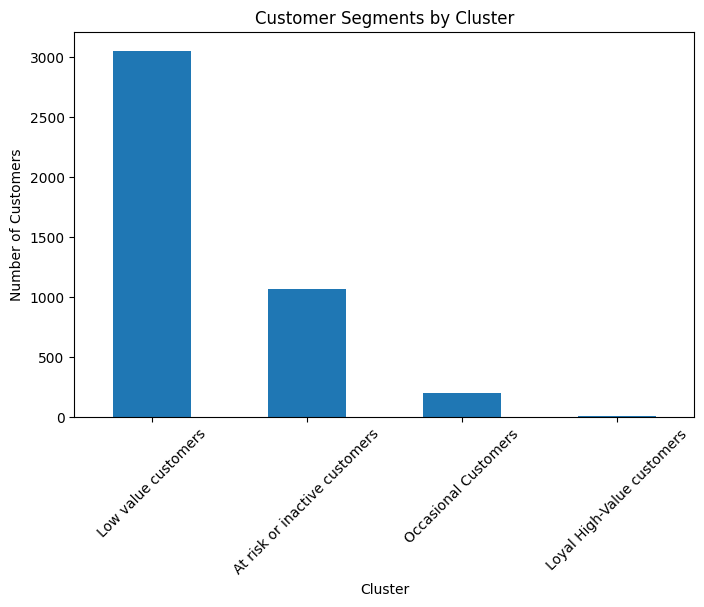

Cluster_Label
Low value customers              3054
At risk or inactive customers    1067
Occasional Customers              204
Loyal High-Value customers         13
Name: count, dtype: int64


In [20]:
rfm["Cluster_Label"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Customer Segments by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()
print(rfm["Cluster_Label"].value_counts())

Both RFM scoring and k-means clustering were applied to segment customers.  
The RFM score approach produced more balanced and interpretable groups, while k-means clustering produced more uneven segment sizes. This difference is expected because RFM scoring is based on predefined score ranges, while k-means identifies groups based on mathematical similarity in the data. Since the RFM score segments were easier to interpret for business recommendations, they were selected as the primary segmentation method for the project.

------------------------------------------------------------------------------------------------------

Final Business Recommendations based on RFM Scoring

- High-value customers should be targeted with loyalty rewards and personalized promotions.
- Mid-value customers could be encouraged to purchase more frequently through upselling and cross-selling campaigns.
- At-risk customers may need win-back offers or re-engagement emails.
- Low-value customers may be best suited for low-cost marketing campaigns.

In [21]:
rfm.to_csv("rfm_segments.csv", index=False)